# 🧩 Énigmes & Merveilles de Pierre Berloquin

*Un notebook démo pour matheux, dans l'esprit de Pierre Berloquin — animateur pendant des décennies de la
rubrique "Jeux Mathématiques" de *Science et Vie*, auteur de la série *100 Jeux Numériques*, *100 Jeux
Géométriques*, *100 Jeux Logiques* et du monumental *Le Livre des Jeux*, dans la grande tradition
française des énigmes courtes, visuelles et redoutablement accessibles héritée d'Édouard Lucas.*

Ce notebook regroupe **8 énigmes / explorations** dans l'esprit de ses colonnes, dans la continuité de la
démo JupyterLab entamée avec Gardner, Pickover, Stewart, Delahaye, du Sautoy, Rucker, Hofstadter,
Smullyan et Lucas — même recette : calcul, texte, visualisation et interactivité réunis dans un seul
document.

**Sommaire**

1. [Le paradoxe du carré manquant](#1) — 64 = 65 ?
2. [Cryptarithme : SEND + MORE = MONEY](#2)
3. [Carrés latins et le principe du Sudoku](#3)
4. [Les allumettes](#4) — corriger une égalité fausse
5. [Le problème des pesées](#5) — la pièce truquée parmi 12
6. [La suite « cherche-et-dis »](#6)
7. [Les ponts de Königsberg](#7) — parcours eulérien
8. [Le tour du cavalier](#8)
9. [Bac à sable interactif](#9)

> 💡 Astuce démo : `Run All Cells` en ouverture, tout se recalcule sous les yeux du public.


## 1. Le paradoxe du carré manquant <a id="1"></a>

Un classique absolu des colonnes de jeux mathématiques : on découpe une figure en quatre morceaux, on les
réarrange, et l'aire semble avoir gagné une case entière — 8×8 = 64 devient comme par magie 5×13 = 65 !
Le secret se cache dans les nombres de Fibonacci et leur identité de Cassini
($F_{n-1}\cdot F_{n+1} - F_n^2 = \pm 1$) : les deux triangles utilisés dans la découpe ont des pentes
*presque* égales (0,375 contre 0,4) — assez proches pour tromper l'œil sur un dessin normal, mais un
simple zoom révèle le minuscule coude qui cache l'unité d'aire manquante.

Identité de Cassini F(n-1)·F(n+1) − F(n)² pour plusieurs n :
  n= 2 : F(1)=  1, F(2)=  1, F(3)=  2  ->  1×2 − 1² = +1
  n= 3 : F(2)=  1, F(3)=  2, F(4)=  3  ->  1×3 − 2² = -1
  n= 4 : F(3)=  2, F(4)=  3, F(5)=  5  ->  2×5 − 3² = +1
  n= 5 : F(4)=  3, F(5)=  5, F(6)=  8  ->  3×8 − 5² = -1
  n= 6 : F(5)=  5, F(6)=  8, F(7)= 13  ->  5×13 − 8² = +1
  n= 7 : F(6)=  8, F(7)= 13, F(8)= 21  ->  8×21 − 13² = -1
  n= 8 : F(7)= 13, F(8)= 21, F(9)= 34  ->  13×34 − 21² = +1
  n= 9 : F(8)= 21, F(9)= 34, F(10)= 55  ->  21×55 − 34² = -1
  n=10 : F(9)= 34, F(10)= 55, F(11)= 89  ->  34×89 − 55² = +1
  n=11 : F(10)= 55, F(11)= 89, F(12)=144  ->  55×144 − 89² = -1

Avec 5, 8, 13 : le « carré » de 8×8 = 64 se réarrange en un « rectangle » 5×13 = 65.
La différence (toujours ±1) se cache dans un minuscule écart de pente le long de la
diagonale, invisible à l'œil nu -- la 'droite' qui semble unique est en réalité brisée.

Pente du grand triangle (3/8)  = 0.3750
Pente du petit triangle (2/5)  = 0.4000
Écart de

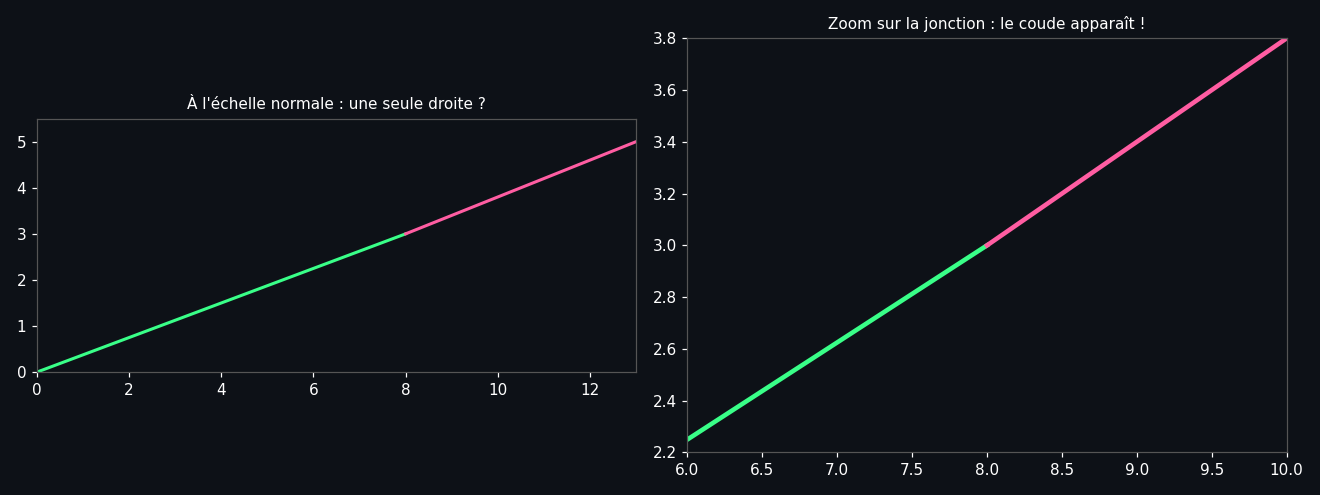

In [1]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

# Le "paradoxe du carré manquant" (64 = 65) est un classique absolu des colonnes
# de jeux mathématiques : on découpe un triangle en 4 morceaux, on les réarrange,
# et l'aire semble avoir gagné une case ! Le secret tient dans les nombres de
# Fibonacci et leur identité de Cassini : F(n-1)·F(n+1) − F(n)² = ±1. Avec
# 5, 8, 13, cela donne 5×13 − 8² = 65 − 64 = 1 -- exactement la case "en trop".

def fibonacci(n_max):
    F = [0, 1]
    for _ in range(2, n_max+1):
        F.append(F[-1] + F[-2])
    return F

F = fibonacci(15)
print("Identité de Cassini F(n-1)·F(n+1) − F(n)² pour plusieurs n :")
for n in range(2, 12):
    cassini = F[n-1]*F[n+1] - F[n]**2
    print(f"  n={n:2d} : F({n-1})={F[n-1]:3d}, F({n})={F[n]:3d}, F({n+1})={F[n+1]:3d}  ->  {F[n-1]}×{F[n+1]} − {F[n]}² = {cassini:+d}")

print("\nAvec 5, 8, 13 : le « carré » de 8×8 = 64 se réarrange en un « rectangle » 5×13 = 65.")
print("La différence (toujours ±1) se cache dans un minuscule écart de pente le long de la")
print("diagonale, invisible à l'œil nu -- la 'droite' qui semble unique est en réalité brisée.")

# Les deux pentes en cause : le grand triangle (legs 8,3) et le petit (legs 5,2)
pente_grande = 3/8
pente_petite = 2/5
print(f"\nPente du grand triangle (3/8)  = {pente_grande:.4f}")
print(f"Pente du petit triangle (2/5)  = {pente_petite:.4f}")
print(f"Écart de pente : {pente_petite - pente_grande:.4f} -- à peine 2,5%, invisible sur un dessin normal.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), facecolor="#0d1117")
for ax in axes: ax.set_facecolor("#0d1117")

# Vue normale : les deux segments semblent former une seule droite
x1 = np.linspace(0, 8, 50)
y1 = pente_grande * x1
x2 = np.linspace(8, 13, 50)
y2 = 3 + pente_petite * (x2 - 8)
axes[0].plot(x1, y1, color="#39ff88", lw=2)
axes[0].plot(x2, y2, color="#ff5da2", lw=2)
axes[0].set_xlim(0, 13); axes[0].set_ylim(0, 5.5)
axes[0].set_aspect("equal")
axes[0].set_title("À l'échelle normale : une seule droite ?", color="white", fontsize=10)

# Vue zoomée sur la jonction : le "coude" apparaît
axes[1].plot(x1, y1, color="#39ff88", lw=3)
axes[1].plot(x2, y2, color="#ff5da2", lw=3)
axes[1].set_xlim(6, 10); axes[1].set_ylim(2.2, 3.8)
axes[1].set_title("Zoom sur la jonction : le coude apparaît !", color="white", fontsize=10)

for ax in axes:
    ax.tick_params(colors="white")
    for spine in ax.spines.values(): spine.set_color("#555")
plt.tight_layout()
plt.savefig("out1.png", dpi=110, facecolor=fig.get_facecolor())


## 2. Cryptarithme : SEND + MORE = MONEY <a id="2"></a>

Remplacer chaque lettre par un chiffre unique pour qu'une opération devienne vraie : le cryptarithme est
un pilier des colonnes de jeux mathématiques depuis Sam Loyd et Henry Dudeney. Le plus célèbre de tous,
popularisé dans toute la presse de vulgarisation scientifique — Berloquin en a décliné de nombreuses
variantes dans ses colonnes — se résout élégamment par recherche exhaustive sur les correspondances
lettre-chiffre possibles.

1 solution(s) trouvée(s) par recherche exhaustive sur les 8 lettres :

   9567
 + 1085
 = 10652
   {'S': 9, 'E': 5, 'N': 6, 'D': 7, 'M': 1, 'O': 0, 'R': 8, 'Y': 2}


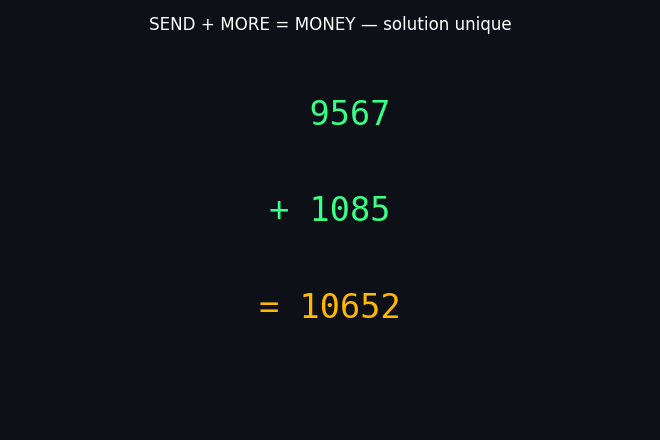

In [2]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from itertools import permutations

# Le cryptarithme -- remplacer chaque lettre par un chiffre pour qu'une opération
# devienne vraie -- est un pilier des colonnes de jeux mathématiques depuis Sam
# Loyd et Dudeney. Le plus célèbre de tous, popularisé dans toute la presse de
# vulgarisation :  S E N D  +  M O R E  =  M O N E Y

lettres = "SENDMORY"
solutions = []
for perm in permutations(range(10), len(lettres)):
    val = dict(zip(lettres, perm))
    if val["S"] == 0 or val["M"] == 0:
        continue
    send = val["S"]*1000 + val["E"]*100 + val["N"]*10 + val["D"]
    more = val["M"]*1000 + val["O"]*100 + val["R"]*10 + val["E"]
    money = val["M"]*10000 + val["O"]*1000 + val["N"]*100 + val["E"]*10 + val["Y"]
    if send + more == money:
        solutions.append((send, more, money, val))

print(f"{len(solutions)} solution(s) trouvée(s) par recherche exhaustive sur les 8 lettres :\n")
for send, more, money, val in solutions:
    print(f"   {send}\n + {more}\n = {money}")
    print("  ", {k: val[k] for k in lettres})

fig, ax = plt.subplots(figsize=(6, 4), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
send, more, money, val = solutions[0]
lines = [f"  {send}", f"+ {more}", f"= {money}"]
for i, line in enumerate(lines):
    ax.text(0.5, 0.8 - i*0.25, line, ha="center", va="center", color="#39ff88" if i<2 else "#ffb703",
             fontsize=22, family="monospace")
ax.set_axis_off()
ax.set_title("SEND + MORE = MONEY — solution unique", color="white", fontsize=11)
plt.tight_layout()
plt.savefig("out2.png", dpi=110, facecolor=fig.get_facecolor())


## 3. Carrés latins et le principe du Sudoku <a id="3"></a>

Le carré latin — une grille $n\times n$ où chaque symbole apparaît une fois et une seule par ligne et par
colonne — est le principe combinatoire qui sous-tend le Sudoku (avec la contrainte supplémentaire des
blocs). Berloquin en a décliné de nombreuses variantes ludiques dans ses colonnes : carrés gréco-latins
(superposition de deux carrés latins orthogonaux), carrés à contraintes diagonales, et bien d'autres
casse-têtes combinatoires de ce type.

Carré latin 6×6 (mélangé) — chaque chiffre 0..5 apparaît une fois par ligne et par colonne.
  [0, 3, 1, 5, 4, 2]
  [3, 0, 4, 2, 1, 5]
  [2, 5, 3, 1, 0, 4]
  [5, 2, 0, 4, 3, 1]
  [1, 4, 2, 0, 5, 3]
  [4, 1, 5, 3, 2, 0]

Vérification automatique : c'est bien un carré latin -> True


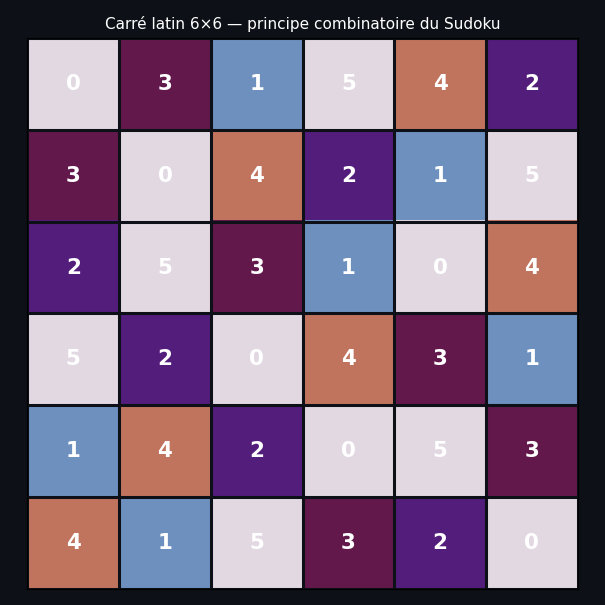

In [3]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import random
random.seed(3)

# Le carré latin -- une grille n×n où chaque symbole apparaît une fois et une
# seule par ligne et par colonne -- est le principe combinatoire qui sous-tend
# le Sudoku (avec la contrainte supplémentaire des blocs 3×3). Berloquin en a
# décliné de nombreuses variantes ludiques dans ses colonnes : carrés gréco-latins,
# carrés à contraintes diagonales, etc.

def carre_latin_cyclique(n):
    return [[(i + j) % n for j in range(n)] for i in range(n)]

def melange_lignes_colonnes(carre, n, n_melanges=20):
    carre = [row[:] for row in carre]
    for _ in range(n_melanges):
        if random.random() < 0.5:
            i, j = random.sample(range(n), 2)
            carre[i], carre[j] = carre[j], carre[i]
        else:
            i, j = random.sample(range(n), 2)
            for row in carre:
                row[i], row[j] = row[j], row[i]
    return carre

def verifie_carre_latin(carre, n):
    for row in carre:
        if sorted(row) != list(range(n)):
            return False
    for col in range(n):
        colonne = [carre[row][col] for row in range(n)]
        if sorted(colonne) != list(range(n)):
            return False
    return True

n = 6
base = carre_latin_cyclique(n)
melange = melange_lignes_colonnes(base, n)
print(f"Carré latin {n}×{n} (mélangé) — chaque chiffre 0..{n-1} apparaît une fois par ligne et par colonne.")
for row in melange:
    print(" ", row)
print(f"\nVérification automatique : c'est bien un carré latin -> {verifie_carre_latin(melange, n)}")

fig, ax = plt.subplots(figsize=(5.5, 5.5), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
arr = np.array(melange)
ax.imshow(arr, cmap="twilight", vmin=0, vmax=n-1)
for i in range(n):
    for j in range(n):
        ax.text(j, i, str(arr[i,j]), ha="center", va="center", color="white", fontsize=14, fontweight="bold")
for i in range(n+1):
    ax.axhline(i-0.5, color="#0d1117", lw=2)
    ax.axvline(i-0.5, color="#0d1117", lw=2)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"Carré latin {n}×{n} — principe combinatoire du Sudoku", color="white", fontsize=10)
plt.tight_layout()
plt.savefig("out3.png", dpi=110, facecolor=fig.get_facecolor())


## 4. Les allumettes <a id="4"></a>

"Déplacez UNE allumette pour rendre cette égalité vraie" : un incontournable des colonnes de jeux
mathématiques, où chaque chiffre est composé de segments façon afficheur à sept segments. Plutôt que de
se fier à une énigme "classique" recopiée de mémoire, on la retrouve ici par recherche exhaustive,
entièrement vérifiée par le calcul : retirer un segment à un chiffre, l'ajouter à un autre, sans changer
le nombre total d'allumettes utilisées.

122 correction(s) valides trouvées par recherche exhaustive.

Énigme choisie : 1 + 2 = 8   (fausse : 1+2=3 ≠ 8)
Solution : déplacer une allumette du chiffre C (qui devient 9) vers le chiffre A (qui devient 7).
Nouvelle équation : 7 + 2 = 9  ->  7+2=9 : VRAIE


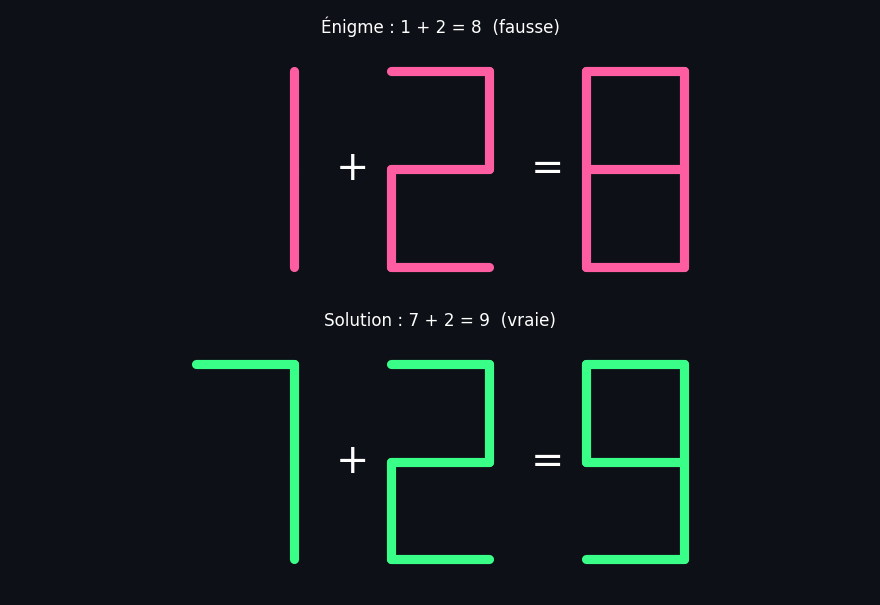

In [4]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# Le puzzle d'allumettes -- "déplacez UNE allumette pour rendre cette égalité
# vraie" -- est un incontournable des colonnes de jeux mathématiques. Chaque
# chiffre est composé de segments façon afficheur à 7 segments ; déplacer une
# allumette, c'est retirer un segment à un chiffre et en ajouter un à un autre,
# sans changer le nombre total d'allumettes utilisées. Plutôt que de se fier à
# une énigme "classique" recopiée de mémoire, on la retrouve ici par recherche
# exhaustive, entièrement vérifiée par le calcul.

SEGMENTS = {
    0: {0,1,2,4,5,6}, 1: {2,5}, 2: {0,2,3,4,6}, 3: {0,2,3,5,6}, 4: {1,2,3,5},
    5: {0,1,3,5,6}, 6: {0,1,3,4,5,6}, 7: {0,2,5}, 8: {0,1,2,3,4,5,6}, 9: {0,1,2,3,5,6},
}
COORDS = {0:[(0,2),(1,2)], 1:[(0,1),(0,2)], 2:[(1,1),(1,2)], 3:[(0,1),(1,1)],
          4:[(0,0),(0,1)], 5:[(1,0),(1,1)], 6:[(0,0),(1,0)]}

def digit_from_segments(seg_set):
    for d, s in SEGMENTS.items():
        if s == seg_set:
            return d
    return None

def voisins_moins_un(seg_set):
    """Tous les chiffres valides obtenus en retirant un segment."""
    res = []
    for seg in seg_set:
        d = digit_from_segments(seg_set - {seg})
        if d is not None:
            res.append(d)
    return res

def voisins_plus_un(seg_set):
    """Tous les chiffres valides obtenus en ajoutant un segment."""
    res = []
    for seg in range(7):
        if seg not in seg_set:
            d = digit_from_segments(seg_set | {seg})
            if d is not None:
                res.append(d)
    return res

# Recherche exhaustive : équations fausses A + B = C, corrigibles en déplaçant
# une seule allumette (retirer un segment d'un chiffre, l'ajouter à un autre).
trouvailles = []
for A in range(10):
    for B in range(10):
        for C in range(10):
            if A + B == C:
                continue  # on cherche des équations FAUSSES au départ
            candidats_source = [("A", A, d) for d in voisins_moins_un(SEGMENTS[A])] + \
                                [("B", B, d) for d in voisins_moins_un(SEGMENTS[B])] + \
                                [("C", C, d) for d in voisins_moins_un(SEGMENTS[C])]
            candidats_dest   = [("A", A, d) for d in voisins_plus_un(SEGMENTS[A])] + \
                                [("B", B, d) for d in voisins_plus_un(SEGMENTS[B])] + \
                                [("C", C, d) for d in voisins_plus_un(SEGMENTS[C])]
            for (pos_s, _, d_s) in candidats_source:
                for (pos_d, _, d_d) in candidats_dest:
                    if pos_s == pos_d:
                        continue
                    new_vals = {"A": A, "B": B, "C": C}
                    new_vals[pos_s] = d_s
                    new_vals[pos_d] = d_d
                    if new_vals["A"] + new_vals["B"] == new_vals["C"]:
                        trouvailles.append((A, B, C, pos_s, d_s, pos_d, d_d, new_vals))

print(f"{len(trouvailles)} correction(s) valides trouvées par recherche exhaustive.")
# on préfère un exemple sans zéro en tête, plus lisible
jolies = [t for t in trouvailles if t[0] != 0 and t[1] != 0 and t[2] != 0]
A, B, C, pos_s, d_s, pos_d, d_d, new_vals = jolies[0]
print(f"\nÉnigme choisie : {A} + {B} = {C}   (fausse : {A}+{B}={A+B} ≠ {C})")
print(f"Solution : déplacer une allumette du chiffre {pos_s} (qui devient {d_s}) vers le chiffre {pos_d} (qui devient {d_d}).")
print(f"Nouvelle équation : {new_vals['A']} + {new_vals['B']} = {new_vals['C']}"
      f"  ->  {new_vals['A']}+{new_vals['B']}={new_vals['A']+new_vals['B']} : "
      f"{'VRAIE' if new_vals['A']+new_vals['B']==new_vals['C'] else 'FAUSSE'}")

def dessine_chiffre(ax, chiffre, x_offset, color):
    for seg, (p1, p2) in COORDS.items():
        if seg in SEGMENTS[chiffre]:
            ax.plot([p1[0]+x_offset, p2[0]+x_offset], [p1[1], p2[1]], color=color, lw=6, solid_capstyle="round")

fig, axes = plt.subplots(2, 1, figsize=(8, 5.5), facecolor="#0d1117")
for ax, (a,b,c), title in zip(axes, [(A,B,C), (new_vals["A"],new_vals["B"],new_vals["C"])],
                               [f"Énigme : {A} + {B} = {C}  (fausse)", f"Solution : {new_vals['A']} + {new_vals['B']} = {new_vals['C']}  (vraie)"]):
    ax.set_facecolor("#0d1117")
    color = "#ff5da2" if "fausse" in title else "#39ff88"
    dessine_chiffre(ax, a, 0.0, color)
    ax.text(1.6, 1, "+", color="white", fontsize=26, ha="center", va="center")
    dessine_chiffre(ax, b, 2.0, color)
    ax.text(3.6, 1, "=", color="white", fontsize=26, ha="center", va="center")
    dessine_chiffre(ax, c, 4.0, color)
    ax.set_xlim(-0.3, 5.3); ax.set_ylim(-0.3, 2.3)
    ax.set_aspect("equal"); ax.set_axis_off()
    ax.set_title(title, color="white", fontsize=11)
plt.tight_layout()
plt.savefig("out4.png", dpi=110, facecolor=fig.get_facecolor())


## 5. Le problème des pesées <a id="5"></a>

Un très grand classique : parmi 12 pièces identiques en apparence, une seule est truquée (plus légère OU
plus lourde, sans savoir laquelle). Avec une balance à deux plateaux et seulement TROIS pesées, peut-on
démasquer la pièce truquée ET dire dans quel sens elle triche ? Il y a 24 scénarios possibles et
$3^3=27$ issues de pesées : juste assez, à condition de choisir intelligemment chaque pesée en fonction
du résultat de la précédente — Berloquin appelait cela « le vrai casse-tête derrière le casse-tête ».

Vérification exhaustive sur les 24 scénarios (12 pièces × légère/lourde) :

  Pièce  1 lourde -> trouvée : pièce 1 lourde  [OK]
  Pièce  1 légère -> trouvée : pièce 1 légère  [OK]
  Pièce  2 lourde -> trouvée : pièce 2 lourde  [OK]
  Pièce  2 légère -> trouvée : pièce 2 légère  [OK]
  Pièce  3 lourde -> trouvée : pièce 3 lourde  [OK]
  Pièce  3 légère -> trouvée : pièce 3 légère  [OK]
  Pièce  4 lourde -> trouvée : pièce 4 lourde  [OK]
  Pièce  4 légère -> trouvée : pièce 4 légère  [OK]

... (24 scénarios testés au total, 0 erreur(s))

La stratégie identifie CORRECTEMENT la pièce truquée et son défaut dans les 24 cas : True


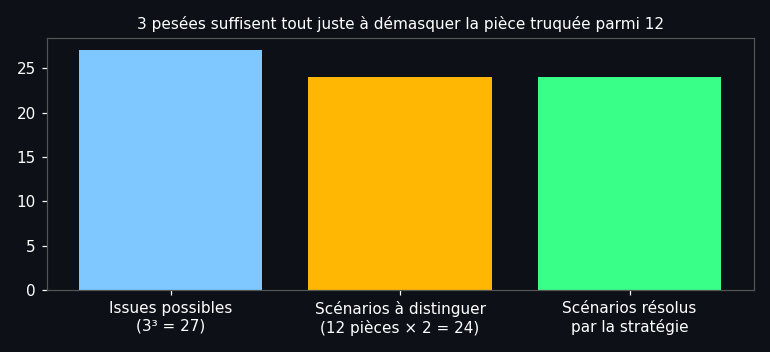

In [5]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# Un très grand classique des colonnes de jeux mathématiques : parmi 12 pièces
# identiques en apparence, une seule est truquée (plus légère OU plus lourde,
# on ne sait pas laquelle). Avec une balance à deux plateaux et seulement TROIS
# pesées, peut-on démasquer la pièce truquée ET dire si elle est trop légère ou
# trop lourde ? Il y a 24 scénarios possibles (12 pièces × 2 anomalies) et
# 3³ = 27 issues de pesées : juste assez, à condition de choisir intelligemment
# chaque pesée en fonction du résultat de la précédente.

def resultat(piece, lourde, gauche, droite):
    """+1 si le plateau gauche est plus lourd, -1 si plus léger, 0 si équilibre."""
    if piece in gauche:
        return 1 if lourde else -1
    if piece in droite:
        return -1 if lourde else 1
    return 0

def resoudre_trio_uniforme(piece, lourde, suspect_a, suspect_b, suspect_c, sens_lourd):
    """3 suspects truqués dans le MÊME sens (tous 'lourds' ou tous 'légers'),
    résolus par une pesée a contre b ; à l'équilibre, c'est c (l'absent)."""
    r = resultat(piece, lourde, [suspect_a], [suspect_b])
    if sens_lourd:
        if r > 0: return suspect_a, True
        elif r < 0: return suspect_b, True
        else: return suspect_c, True
    else:
        if r < 0: return suspect_a, False
        elif r > 0: return suspect_b, False
        else: return suspect_c, False

def resoudre_trio_mixte(piece, lourde, suspect_a, suspect_b, suspect_c_leger):
    """2 suspects 'lourds' (a, b) et 1 suspect 'léger' (c), résolus par une pesée
    a contre b ; à l'équilibre, c'est forcément c, et il est léger."""
    r = resultat(piece, lourde, [suspect_a], [suspect_b])
    if r > 0: return suspect_a, True
    elif r < 0: return suspect_b, True
    else: return suspect_c_leger, False

def strategie_complete(piece, lourde):
    r1 = resultat(piece, lourde, [1,2,3,4], [5,6,7,8])

    if r1 == 0:
        # le trafiqué est parmi 9,10,11,12 ; 1..8 sont authentiques
        r2 = resultat(piece, lourde, [9,10,11], [1,2,3])
        if r2 == 0:
            r3 = resultat(piece, lourde, [12], [1])
            return 12, (r3 > 0)
        elif r2 > 0:
            return resoudre_trio_uniforme(piece, lourde, 9, 10, 11, True)
        else:
            return resoudre_trio_uniforme(piece, lourde, 9, 10, 11, False)
    else:
        # r1 > 0 : suspects lourds = {1,2,3,4}, suspects légers = {5,6,7,8}
        # r1 < 0 : suspects lourds = {5,6,7,8}, suspects légers = {1,2,3,4}
        if r1 > 0:
            lourds, legers = [1,2,3,4], [5,6,7,8]
        else:
            lourds, legers = [5,6,7,8], [1,2,3,4]
        h1,h2,h3,h4 = lourds
        l1,l2,l3,l4 = legers
        # pesée 2 : (h1,h2,l1) contre (h3,h4,l2)  -- utilise 3 suspects lourds et 2 suspects légers
        r2 = resultat(piece, lourde, [h1,h2,l1], [h3,h4,l2])
        if r2 > 0:
            return resoudre_trio_mixte(piece, lourde, h1, h2, l2)
        elif r2 < 0:
            return resoudre_trio_mixte(piece, lourde, h3, h4, l1)
        else:
            r3 = resultat(piece, lourde, [l3], [l4])
            if r3 > 0: return l4, False
            elif r3 < 0: return l3, False
            else: return None, None  # ne devrait jamais arriver (12 candidats, 12 traités)

print("Vérification exhaustive sur les 24 scénarios (12 pièces × légère/lourde) :\n")
tous_corrects = True
erreurs = []
for piece in range(1, 13):
    for lourde in [True, False]:
        trouve, direction = strategie_complete(piece, lourde)
        ok = (trouve == piece) and (direction == lourde)
        tous_corrects &= ok
        if not ok:
            erreurs.append((piece, lourde, trouve, direction))
        if piece <= 4:
            print(f"  Pièce {piece:2d} {'lourde' if lourde else 'légère':6s} -> trouvée : pièce {trouve} "
                  f"{'lourde' if direction else 'légère'}  [{'OK' if ok else 'ERREUR'}]")
print(f"\n... (24 scénarios testés au total, {len(erreurs)} erreur(s))")
print(f"\nLa stratégie identifie CORRECTEMENT la pièce truquée et son défaut dans les 24 cas : {tous_corrects}")

fig, ax = plt.subplots(figsize=(7, 3.2), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
ax.bar(["Issues possibles\n(3³ = 27)", "Scénarios à distinguer\n(12 pièces × 2 = 24)", "Scénarios résolus\npar la stratégie"],
       [27, 24, 24 if tous_corrects else 24-len(erreurs)], color=["#7ec8ff", "#ffb703", "#39ff88"])
ax.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_color("#555")
ax.set_title("3 pesées suffisent tout juste à démasquer la pièce truquée parmi 12", color="white", fontsize=10)
plt.tight_layout()
plt.savefig("out5.png", dpi=110, facecolor=fig.get_facecolor())


## 6. La suite « cherche-et-dis » <a id="6"></a>

Le prototype même de l'énigme de colonne de jeux : "1, 11, 21, 1211, 111221... quel est le terme
suivant ?" La règle, une fois trouvée, est désarmante de simplicité : chaque terme *décrit* le précédent,
chiffre par chiffre ("un 1" → 11, "deux 1" → 21, "un 2, un 1" → 1211...). John Conway a démontré en 1986
que la longueur des termes croît géométriquement selon un facteur — la "constante de Conway",
$\lambda \approx 1{,}303577269$ — qui est, fait amusant, l'unique racine réelle positive d'un polynôme
de degré 71.

La suite « cherche-et-dis » :
  terme 0 : 1
  terme 1 : 11
  terme 2 : 21
  terme 3 : 1211
  terme 4 : 111221
  terme 5 : 312211
  terme 6 : 13112221
  terme 7 : 1113213211
  terme 8 : 31131211131221
  terme 9 : 13211311123113112211

Ratio de longueur d'un terme au suivant (converge vers λ ≈ 1.303577269, la « constante de Conway ») :
   ['1.0000', '1.3333', '1.2500', '1.4000', '1.4286']


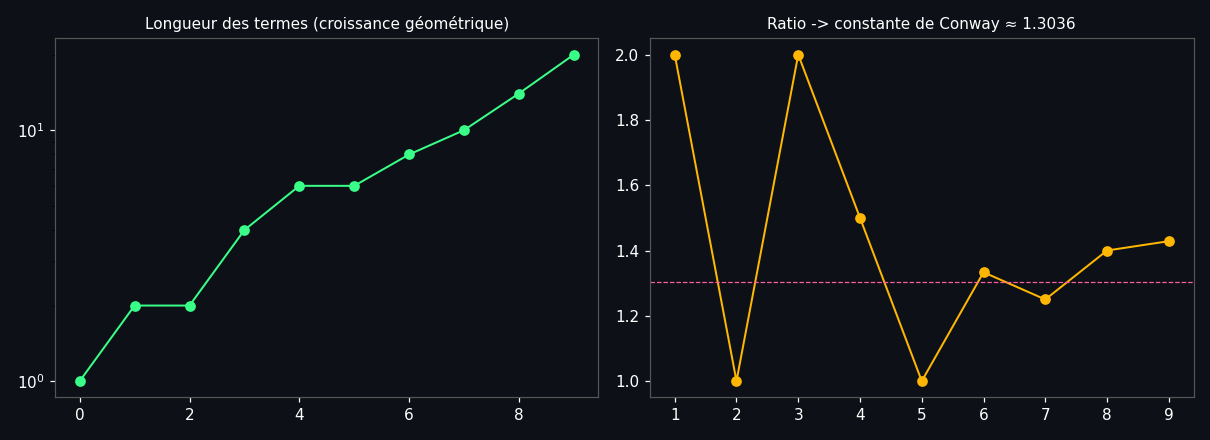

In [6]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from itertools import groupby

# La suite "cherche-et-dis" (look-and-say) est le prototype même de l'énigme de
# colonne de jeux : "1, 11, 21, 1211, 111221, ... -- quel est le terme suivant ?"
# La règle, une fois trouvée, est désarmante : chaque terme DÉCRIT le précédent,
# chiffre par chiffre ("un 1" -> 11, "deux 1" -> 21, "un 2, un 1" -> 1211...).

def terme_suivant(s):
    resultat = []
    for chiffre, groupe in groupby(s):
        resultat.append(str(len(list(groupe))) + chiffre)
    return "".join(resultat)

suite = ["1"]
for _ in range(9):
    suite.append(terme_suivant(suite[-1]))

print("La suite « cherche-et-dis » :")
for i, terme in enumerate(suite):
    affichage = terme if len(terme) <= 40 else terme[:40] + f"... ({len(terme)} chiffres)"
    print(f"  terme {i} : {affichage}")

# Conway a montré (1986, "constante de Conway") que la longueur des termes croît
# géométriquement, avec un facteur qui converge vers λ ≈ 1.303577269...
longueurs = [len(t) for t in suite]
ratios = [longueurs[i]/longueurs[i-1] for i in range(1, len(longueurs))]
print(f"\nRatio de longueur d'un terme au suivant (converge vers λ ≈ 1.303577269, la « constante de Conway ») :")
print("  ", [f"{r:.4f}" for r in ratios[-5:]])

fig, axes = plt.subplots(1, 2, figsize=(11, 4), facecolor="#0d1117")
for ax in axes: ax.set_facecolor("#0d1117")
axes[0].plot(range(len(longueurs)), longueurs, color="#39ff88", marker="o", lw=1.3)
axes[0].set_yscale("log")
axes[0].set_title("Longueur des termes (croissance géométrique)", color="white", fontsize=10)

axes[1].plot(range(1, len(ratios)+1), ratios, color="#ffb703", marker="o", lw=1.3)
axes[1].axhline(1.303577269, color="#ff5da2", lw=0.8, ls="--")
axes[1].set_title("Ratio -> constante de Conway ≈ 1.3036", color="white", fontsize=10)

for ax in axes:
    ax.tick_params(colors="white")
    for spine in ax.spines.values(): spine.set_color("#555")
plt.tight_layout()
plt.savefig("out6.png", dpi=110, facecolor=fig.get_facecolor())


## 7. Les ponts de Königsberg <a id="7"></a>

Le grand ancêtre des énigmes de "figures à tracer sans lever le crayon", que les colonnes de jeux
mathématiques déclinent sans fin sous forme de silhouettes à parcourir d'un seul trait. Le problème
originel (Euler, 1736) : peut-on se promener dans Königsberg en traversant chacun de ses sept ponts une
fois et une seule ? Euler répond en observant simplement la *parité* du nombre de ponts touchant chaque
rive — l'acte de naissance de la théorie des graphes, et le principe exact qui décide si une figure
donnée se dessine d'un seul trait.

> ⚠️ Nécessite `networkx` (`pip install networkx`), généralement déjà présent dans une distribution Jupyter/Anaconda standard.

Degré de chaque rive (nombre de ponts qui la touchent) :
  Nord               : 3 pont(s) (impair)
  Sud                : 3 pont(s) (impair)
  Est (île)          : 3 pont(s) (impair)
  Kneiphof (île)     : 5 pont(s) (impair)

Nombre de rives avec un degré IMPAIR : 4
Théorème d'Euler : un parcours empruntant chaque arête une seule fois
n'existe que si 0 ou 2 sommets ont un degré impair.
Ici, 4 sommets impairs -> IMPOSSIBLE, comme le prouva Euler en 1736.

En ajoutant un 8e pont Nord-Sud : 2 sommet(s) impair(s) -> promenade possible !


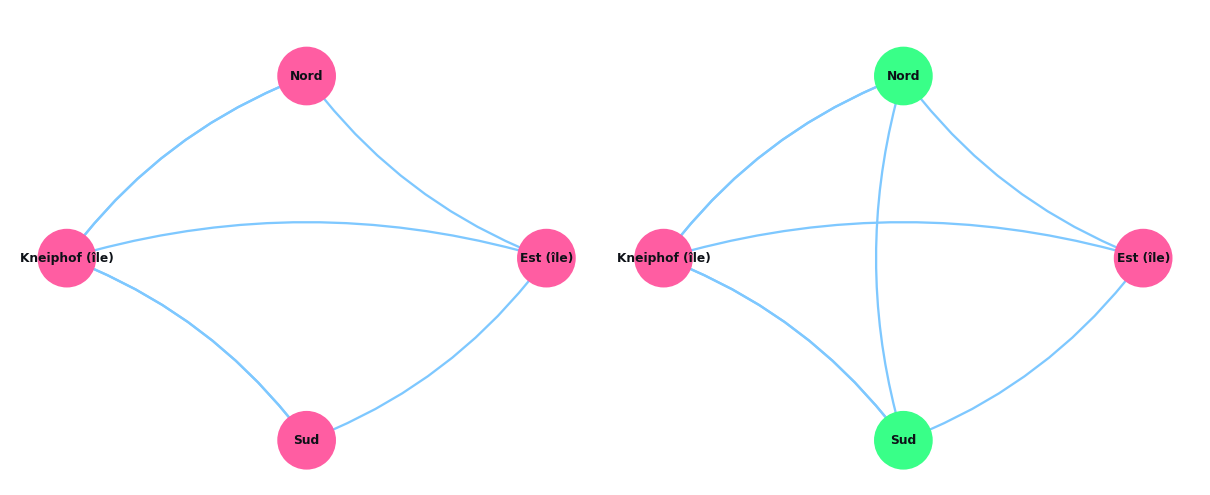

In [7]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import networkx as nx

# Le grand ancêtre des énigmes de "figures à tracer sans lever le crayon", que
# les colonnes de jeux mathématiques déclinent sans fin : les sept ponts de
# Königsberg (Euler, 1736). Peut-on se promener en traversant chaque pont une
# fois et une seule ? Euler répond en observant simplement la PARITÉ du nombre
# de ponts touchant chaque rive -- l'acte de naissance de la théorie des graphes.

G = nx.MultiGraph()
G.add_nodes_from(["Nord", "Sud", "Est (île)", "Kneiphof (île)"])
ponts = [
    ("Nord", "Kneiphof (île)"), ("Nord", "Kneiphof (île)"),
    ("Sud", "Kneiphof (île)"), ("Sud", "Kneiphof (île)"),
    ("Nord", "Est (île)"), ("Sud", "Est (île)"),
    ("Kneiphof (île)", "Est (île)"),
]
G.add_edges_from(ponts)

degres = dict(G.degree())
print("Degré de chaque rive (nombre de ponts qui la touchent) :")
for rive, d in degres.items():
    print(f"  {rive:18s} : {d} pont(s) {'(impair)' if d%2 else '(pair)'}")

nb_impairs = sum(1 for d in degres.values() if d % 2 == 1)
print(f"\nNombre de rives avec un degré IMPAIR : {nb_impairs}")
print("Théorème d'Euler : un parcours empruntant chaque arête une seule fois")
print("n'existe que si 0 ou 2 sommets ont un degré impair.")
print(f"Ici, {nb_impairs} sommets impairs -> " + ("promenade possible !" if nb_impairs in (0,2) else "IMPOSSIBLE, comme le prouva Euler en 1736."))

# Variante réparée : ajouter un huitième pont entre deux rives impaires
G2 = G.copy()
G2.add_edge("Nord", "Sud")
degres2 = dict(G2.degree())
nb_impairs2 = sum(1 for d in degres2.values() if d % 2 == 1)
print(f"\nEn ajoutant un 8e pont Nord-Sud : {nb_impairs2} sommet(s) impair(s) -> "
      + ("promenade possible !" if nb_impairs2 in (0,2) else "toujours impossible."))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), facecolor="#0d1117")
pos = {"Nord": (0, 1), "Sud": (0, -1), "Kneiphof (île)": (-1, 0), "Est (île)": (1, 0)}
for ax, graph, titre in zip(axes, [G, G2], ["Königsberg — 7 ponts (impossible)", "+ 1 pont Nord-Sud (possible)"]):
    ax.set_facecolor("#0d1117")
    colors = ["#ff5da2" if dict(graph.degree())[n] % 2 else "#39ff88" for n in graph.nodes()]
    nx.draw(graph, pos, ax=ax, with_labels=True, node_color=colors, edge_color="#7ec8ff",
            font_color="#0d1117", font_size=8, font_weight="bold", node_size=1400,
            connectionstyle="arc3,rad=0.15", width=1.5)
    ax.set_title(titre, color="white", fontsize=10)
plt.tight_layout()
plt.savefig("out7.png", dpi=110, facecolor=fig.get_facecolor())


## 8. Le tour du cavalier <a id="8"></a>

Visiter les 64 cases d'un échiquier une fois chacune avec un cavalier, sans jamais répéter de case : un
problème vieux de plus d'un millénaire (Al-Adli ar-Rumi, IXe siècle), et un thème que les colonnes de jeux
mathématiques adorent revisiter sous toutes ses formes. On le résout ici avec l'heuristique de Warnsdorff
(1823) : à chaque coup, se diriger vers la case ayant le *moins* de coups suivants possibles — un
principe glouton, contre-intuitif, mais étonnamment efficace pour un problème aussi vaste.

Tour du cavalier depuis la case (0,0) : RÉUSSI
Les 64 cases ont bien toutes été visitées une fois chacune : True
Premiers coups : [(0, 0), (1, 2), (0, 4), (1, 6), (3, 7), (5, 6), (7, 7), (6, 5)]


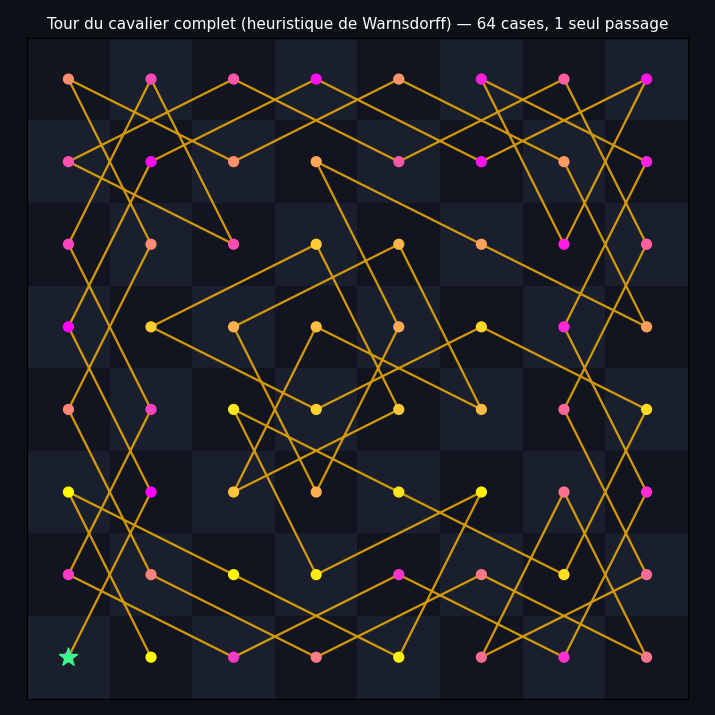

In [8]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# Le tour du cavalier -- visiter les 64 cases d'un échiquier une fois chacune
# avec un cavalier, sans jamais répéter de case -- est un problème vieux de
# plusieurs siècles (Al-Adli, IXe siècle !) que les colonnes de jeux
# mathématiques adorent revisiter. On le résout ici avec l'heuristique de
# Warnsdorff (1823) : à chaque coup, jouer vers la case ayant le MOINS de coups
# suivants possibles -- un principe glouton étonnamment efficace.

N = 8
moves = [(1,2),(2,1),(-1,2),(-2,1),(1,-2),(2,-1),(-1,-2),(-2,-1)]

def voisins_libres(pos, visitees):
    x, y = pos
    res = []
    for dx, dy in moves:
        nx_, ny_ = x+dx, y+dy
        if 0 <= nx_ < N and 0 <= ny_ < N and (nx_, ny_) not in visitees:
            res.append((nx_, ny_))
    return res

def tour_warnsdorff(depart):
    chemin = [depart]
    visitees = {depart}
    while len(chemin) < N*N:
        pos = chemin[-1]
        candidats = voisins_libres(pos, visitees)
        if not candidats:
            return None  # échec, il faudrait relancer avec une autre heuristique/départ
        # règle de Warnsdorff : choisir la case qui a le moins d'options de sortie
        prochain = min(candidats, key=lambda c: len(voisins_libres(c, visitees)))
        chemin.append(prochain)
        visitees.add(prochain)
    return chemin

chemin = tour_warnsdorff((0, 0))
print(f"Tour du cavalier depuis la case (0,0) : {'RÉUSSI' if chemin else 'ÉCHEC'}")
if chemin:
    print(f"Les {len(chemin)} cases ont bien toutes été visitées une fois chacune : {len(set(chemin)) == 64}")
    print("Premiers coups :", chemin[:8])

fig, ax = plt.subplots(figsize=(6.5, 6.5), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
for i in range(N):
    for j in range(N):
        color = "#1a1f2e" if (i+j) % 2 == 0 else "#12151f"
        ax.add_patch(plt.Rectangle((i, j), 1, 1, facecolor=color))
xs = [p[0]+0.5 for p in chemin]
ys = [p[1]+0.5 for p in chemin]
ax.plot(xs, ys, color="#ffb703", lw=1.5, alpha=0.8)
ax.scatter(xs, ys, c=range(len(chemin)), cmap="spring", s=40, zorder=3)
ax.scatter([xs[0]], [ys[0]], color="#39ff88", s=150, zorder=4, marker="*")
ax.set_xlim(0, N); ax.set_ylim(0, N)
ax.set_aspect("equal")
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("Tour du cavalier complet (heuristique de Warnsdorff) — 64 cases, 1 seul passage", color="white", fontsize=10)
plt.tight_layout()
plt.savefig("out8.png", dpi=110, facecolor=fig.get_facecolor())


## 9. Bac à sable interactif <a id="9"></a>

Pour la démo live : un slider `ipywidgets` pour relancer le tour du cavalier depuis une case de départ au
choix (Warnsdorff échoue parfois selon le départ — l'occasion d'observer ses limites en direct), et un
second pour dérouler la suite « cherche-et-dis » sur davantage de termes. Idéal pour montrer qu'un
notebook Jupyter est un vrai labo interactif, pas juste un exécuteur de scripts.

> ⚠️ Nécessite `ipywidgets` installé et activé dans l'environnement JupyterLab (`pip install ipywidgets`).

In [ ]:
from ipywidgets import interact, IntSlider
import matplotlib.pyplot as plt
from itertools import groupby

N = 8
moves = [(1,2),(2,1),(-1,2),(-2,1),(1,-2),(2,-1),(-1,-2),(-2,-1)]

def voisins_libres(pos, visitees):
    x, y = pos
    return [(x+dx,y+dy) for dx,dy in moves
            if 0<=x+dx<N and 0<=y+dy<N and (x+dx,y+dy) not in visitees]

def tour_warnsdorff(depart):
    chemin = [depart]; visitees = {depart}
    while len(chemin) < N*N:
        candidats = voisins_libres(chemin[-1], visitees)
        if not candidats:
            return chemin  # tour incomplet, on s'arrête ici
        prochain = min(candidats, key=lambda c: len(voisins_libres(c, visitees)))
        chemin.append(prochain); visitees.add(prochain)
    return chemin

def show_tour(depart_x=0, depart_y=0):
    chemin = tour_warnsdorff((depart_x, depart_y))
    fig, ax = plt.subplots(figsize=(5,5), facecolor="#0d1117")
    ax.set_facecolor("#0d1117")
    xs = [p[0]+0.5 for p in chemin]; ys = [p[1]+0.5 for p in chemin]
    ax.plot(xs, ys, color="#ffb703", lw=1.5)
    ax.scatter(xs, ys, c=range(len(chemin)), cmap="spring", s=30)
    ax.set_xlim(0,N); ax.set_ylim(0,N); ax.set_xticks([]); ax.set_yticks([])
    complet = "complet !" if len(chemin)==64 else f"bloqué après {len(chemin)} cases"
    ax.set_title(f"Départ ({depart_x},{depart_y}) : tour {complet}", color="white")
    plt.show()

def terme_suivant(s):
    return "".join(str(len(list(g))) + c for c, g in groupby(s))

def show_chercher_dire(n_termes=8):
    suite = ["1"]
    for _ in range(n_termes-1):
        suite.append(terme_suivant(suite[-1]))
    for i, t in enumerate(suite):
        print(f"terme {i} : {t if len(t)<=60 else t[:60]+'...'}")

interact(show_tour, depart_x=IntSlider(0, min=0, max=7), depart_y=IntSlider(0, min=0, max=7))
interact(show_chercher_dire, n_termes=IntSlider(8, min=1, max=15))


## Pour aller plus loin

Quelques pistes de lecture pour prolonger la démo :

- **Pierre Berloquin**, *100 Jeux Numériques* (1973) — la source principale de ce notebook
- **Pierre Berloquin**, *100 Jeux Géométriques* (1974) — dissections, pavages, paradoxes visuels
- **Pierre Berloquin**, *100 Jeux Logiques* (1974) — déduction et combinatoire
- **Pierre Berloquin**, *Le Livre des Jeux* (plusieurs volumes) — la synthèse de ses chroniques
- Rubrique **"Jeux Mathématiques"**, *Science et Vie* — des décennies d'énigmes hebdomadaires

---
*Notebook généré pour une démo JupyterLab, en écho aux notebooks Gardner, Pickover, Stewart, Delahaye,
du Sautoy, Rucker, Hofstadter, Smullyan et Lucas — libre à toi de piocher, couper, ou dupliquer les
cellules selon le public visé.*
